Datetime 패키지
- datetime 패키지는 파이썬에서 날짜와 시간을 다룰 수 있느 내장 모듈

timedelta

timedelta 클래스는 기간(시간 간격)을 표현하기 위해서 사용
- weeks, days, hours, minutes, seconds, milliseconds, microseconds 속성을 사용하여 시간 간격을 생성
- 저장은 일, 초, 마이크로 초 단위만 저장

In [1]:
from datetime import timedelta

# 1일+1시간+1분+1초+1밀리초
td = timedelta(days=1, hours=1, minutes=1, seconds=1, milliseconds=1 )

print(td)

1 day, 1:01:01.001000


timezone

In [2]:
from datetime import timezone

# 한국 표준시
KST = timezone(timedelta(hours=9))

print(KST)

UTC+09:00


time

- time(): 시간을 표현하기 위한 클래스
    - hour, minute, second, microsecond, tzinfo 속성을 사용하여 시간을 생성
- time.isoformat(): time 객체를 'HH:MM:SS.nanoseconds+timezone'형식의 문자열로 반환
- time.sleep(): 일정 시간동안 프로그램을 멈추는 함수

In [3]:
from datetime import time

# 13시 42분 35초 458밀리초, 한국 표준시
t1 = time(13, 42, 35, 458000, tzinfo=KST)

print(t1)
print(f'{type(t1) = }')
print(f'{t1.isoformat() = }')

13:42:35.458000+09:00
type(t1) = <class 'datetime.time'>
t1.isoformat() = '13:42:35.458000+09:00'


In [4]:
# 개별값 확인
print(f'{t1.hour = }')
print(f'{t1.minute = }')
print(f'{t1.second = }')
print(f'{t1.microsecond = }')
print(f'{t1.tzinfo = }')

t1.hour = 13
t1.minute = 42
t1.second = 35
t1.microsecond = 458000
t1.tzinfo = datetime.timezone(datetime.timedelta(seconds=32400))


date

- date(): 날짜를 표현하기 위한 클래스
    - year, month, day 속성을 사용하여 날짜를 생성
- date.isoformat(): date 객체를 'YYYY-MM-DD' 형식의 문자열로 변환
- date.today(): 오늘 날짜를 반환

In [5]:
from datetime import date

# 2025년 1월 1일
d1 = date(year=2025, month=1, day=1)

print(d1)
print(f'{type(d1) = }')
print(f'{d1.isoformat() = }')

2025-01-01
type(d1) = <class 'datetime.date'>
d1.isoformat() = '2025-01-01'


- weekday()(월요일 0)와 isoweekday()(월요일1) 메서드는 해당 날짜가 무슨 요일인지를 파악하기 위해서 사용

In [6]:
print(f'{d1.year = }')
print(f'{d1.month = }')
print(f'{d1.day = }')
print(f'{d1.weekday() = }') # 월요일: 0, 일요일: 6
print(f'{d1.isoweekday() = }') # 월요일: 1, 일요일: 7

d1.year = 2025
d1.month = 1
d1.day = 1
d1.weekday() = 2
d1.isoweekday() = 3


In [7]:
# 오늘 날짜
today = date.today()

# 오늘부터 1주일 후 날짜
next_week = today + timedelta(days=7)

print(today)
print(next_week)

2026-05-03
2026-05-10


datetime

- datetime(): 날짜와 시간을 동시에 표현하기 위한 클래스
    - year, month, day, hour, minute, second, microsecond, tzinfo 속성을 사용하여 날짜와 시간을 생성
- datetime.isoformat(): datetime 객체를 'YYYY-MM-DDTHH:MM:SS.nanoseconds+timezone' 형식의 문자열로 변환
- datetime.now(): 현재 날짜와 시간을 반환

In [8]:
from datetime import datetime

dt1 = datetime(year=2025, month=1, day=1, 
               hour=13, minute=42, second=35,
               microsecond=458000, tzinfo=timezone(timedelta(hours=9)))

print(dt1)
print(f'{type(dt1) = }')
print(f'{dt1.isoformat() = }')


2025-01-01 13:42:35.458000+09:00
type(dt1) = <class 'datetime.datetime'>
dt1.isoformat() = '2025-01-01T13:42:35.458000+09:00'


In [9]:
# 현재 날짜와 시간
current = datetime.now()

after_1_hour = current + timedelta(hours=1)
before_1_day = current - timedelta(days=1)

print(current)
print(after_1_hour)
print(before_1_day)

2026-05-03 22:40:16.705835
2026-05-03 23:40:16.705835
2026-05-02 22:40:16.705835


combine

- combine() 메서드는 date 객체와 time 객체를 합쳐 datetime 객체로 만들어줌

In [10]:
# date와 time을 연결
date_time = datetime.combine(date(2023,7,11), time(19,27,30))

print(date_time)

2023-07-11 19:27:30


strftime

- strftime(): datetime을 다양한 문자열로 변경
    - %y: 두 자리 수의 연도, %Y: 네 자리 수의 연도, %m: 월, %d:일
    - %I(로마자 1..12시제): 12시간제의 시간, %H(High.. 더 높이): 24시간제의 시간, %p: AM/PM
    - %M: 분, %S: 초, %f: 마이크로 초
    - %a(abbreviated, Mon): 요일의 약자, %A(all name, Monday): 요일의 fullname
    - %b(brief, Jan): 월의 약자, %B(Big name, January): 월의 fullname
    - %U(united states): 연중 주차(일요일 시작), %W(working day): 연중 주차(월요일 시작), %j: 연중 일 수
    - %c(complete): 날짜+시간 문자열(Tue Aug 16 21:20:00 1988), %x(xxxx-xx-xx): 날짜 문자열(08/16/88), %X(시계바늘 교차): 시간 문자열(21:30:00)

- 가장 기본이 되는 규칙은 대문자가 더 정보량이 많거나 길다!

In [11]:
# 날짜 표시
date.today().strftime('%Y-%y-%m-%d')

'2026-26-05-03'

In [12]:
# 시간 표시
datetime.now().strftime('%I-%H-%p-%M-%S-%f')

'10-22-PM-40-16-750470'

In [13]:
# 요일/월 표시
date.today().strftime('%a-%A-%b-%B')

'Sun-Sunday-May-May'

In [14]:
# 주차/일차 표시
date.today().strftime('%U주차-%W주차-%j일차')

'18주차-17주차-123일차'

In [15]:
# 기타 표시
date.today().strftime('%d-%x-%X')

'03-05/03/26-00:00:00'

strptime(string parse time)

- strptime()은 문자열을 datetime 객체로 변경할 수 있음
    - 첫 번째 인자는 문자열, 두 번째 인자는 문자열의 형식

In [16]:
datetime.strptime('2023-07-11 19:27:30', '%Y-%m-%d %H:%M:%S')

datetime.datetime(2023, 7, 11, 19, 27, 30)

### time 패키지

sleep

- time.sleep(): 일정 시간동안 프로그램을 멈추는 함수
    - 인자로 초 단위의 시간을 입력

In [17]:
import time

# 현재 시간
start=datetime.now()

time.sleep(5)
print(datetime.now()-start)

time.sleep(5)
print(datetime.now()-start)

0:00:05.010509
0:00:10.021967


dateutil 패키지

- dateutil 패키지는 날짜 시간 문자열을 자동으로 parsing 해주는 파이썬 내장 모듈

In [18]:
from dateutil.parser import parse

# 문자열을 datetime으로 변환
parse('2023-7-11, 07:39:30 PM')

datetime.datetime(2023, 7, 11, 19, 39, 30)

In [19]:
# 문자열을 datetime으로 변환
parse('19:39:30, sep/10/2023')

datetime.datetime(2023, 9, 10, 19, 39, 30)

### Pandas

- Pandas에서는 시계열 데이터를 다루기 위한 다양한 기능을 제공하므로, 시계열 데이터를 전처리, 피쳐엔지니어링, 분석, 시각화하기 위해서는 기본 데이터 유형으로 Pandas DataFrame을 사용하는 것이 편리함.

시계열 인덱스
- Pandas에서 시계열 데이터는 인덱스(index)가 시간, 날짜, 기간인 자료형으로 만들어야 함

시계열 인덱스의 유형
- DatetimeIndex: 특정한 시간(timestamp)을 표현
- PeriodIndex: 시간(timestamp) 사이에 기간(period)을 표현
- TimedeltaIndex: 기간(period)의 길이를 표현

DatetimeIndex
- DatetimeIndex 생성

In [20]:
import pandas as pd

# 날짜의 유형은 다양하게 사용 가능
pd.DatetimeIndex(["2020, 1, 5", "2021-1-6", "2022/1/7", "1/8/2023 11:00:00"])

DatetimeIndex(['2020-01-05 00:00:00', '2021-01-06 00:00:00',
               '2022-01-07 00:00:00', '2023-01-08 11:00:00'],
              dtype='datetime64[ns]', freq=None)

- date_range()를 사용한 DatetimeIndex 생성
    - start와 end로 시작과 끝을 지정
    - period로 데이터의 갯수 지정
    - freq로 간격을 지정
        - W: 주(week), D: 일(day), h: 시(hour), min: 분(minute), s: 초(second), ms: 밀리초(millisecond), us: 마이크로초(microsecond)
        - YS: 연(year)의 시작, YE: 연(year)의 끝
        - MS: 월의 시작, ME: 월의 끝, SME(semi month end): 15일을 기준
        - QS: 분기의 시작, Q: 분기의 끝

In [21]:
# 날짜 범위 생성
pd.date_range(start='2025-1-1', end='2025-1-4', freq='D')

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04'], dtype='datetime64[ns]', freq='D')

(my): freq='2W'이라고만 쓰면, Week 기준을 일요일로 보고, 일요일 기준 날짜 세기를 함

In [22]:
# 날짜 범위 생성
print(pd.date_range(start='2025-1-1', periods=3, freq='2W'))
print(pd.date_range(start='2025-1-1', periods=3, freq='3D'))
print(pd.date_range(start='2025-1-1', periods=3, freq='h'))
print(pd.date_range(start='2025-1-1', periods=3, freq='min'))
print(pd.date_range(start='2025-1-1', periods=3, freq='s'))

DatetimeIndex(['2025-01-05', '2025-01-19', '2025-02-02'], dtype='datetime64[ns]', freq='2W-SUN')
DatetimeIndex(['2025-01-01', '2025-01-04', '2025-01-07'], dtype='datetime64[ns]', freq='3D')
DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 01:00:00',
               '2025-01-01 02:00:00'],
              dtype='datetime64[ns]', freq='h')
DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 00:01:00',
               '2025-01-01 00:02:00'],
              dtype='datetime64[ns]', freq='min')
DatetimeIndex(['2025-01-01 00:00:00', '2025-01-01 00:00:01',
               '2025-01-01 00:00:02'],
              dtype='datetime64[ns]', freq='s')


In [23]:
# 날짜 범위 생성
print(pd.date_range(start='2025-1-1', periods=3, freq='YS'))
print(pd.date_range(start='2025-1-1', periods=3, freq='YE'))

DatetimeIndex(['2025-01-01', '2026-01-01', '2027-01-01'], dtype='datetime64[ns]', freq='YS-JAN')
DatetimeIndex(['2025-12-31', '2026-12-31', '2027-12-31'], dtype='datetime64[ns]', freq='YE-DEC')


In [24]:
# 날짜 범위 생성
print(pd.date_range(start='2025-1-1', periods=3, freq='MS'))
print(pd.date_range(start='2025-1-1', periods=3, freq='ME'))
print(pd.date_range(start='2025-1-1', periods=4, freq='SME'))


DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01'], dtype='datetime64[ns]', freq='MS')
DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31'], dtype='datetime64[ns]', freq='ME')
DatetimeIndex(['2025-01-15', '2025-01-31', '2025-02-15', '2025-02-28'], dtype='datetime64[ns]', freq='SME-15')


In [25]:
# 날짜 범위 생성
print(pd.date_range(start='2025-1-1', periods=3, freq='QS'))
print(pd.date_range(start='2025-1-1', periods=3, freq='QE'))

DatetimeIndex(['2025-01-01', '2025-04-01', '2025-07-01'], dtype='datetime64[ns]', freq='QS-JAN')
DatetimeIndex(['2025-03-31', '2025-06-30', '2025-09-30'], dtype='datetime64[ns]', freq='QE-DEC')


PeriodIndex
- PeriodIndex()를 사용한 PeriodIndex 생성
    - start와 end로 시작과 끝을 지정
    - periods로 데이터의 갯수 지정
    - freq로 간격을 지정
        - D: 일, W: 주, M: 월, Q: 분기, Y: 연
        - h: 시, min: 분, s: 초

In [26]:
import pandas as pd

# PeriodIndex 생성
pd.PeriodIndex(['2020-1', '2021-2', '2022-3', '2023-4'], freq='M')

PeriodIndex(['2020-01', '2021-02', '2022-03', '2023-04'], dtype='period[M]')

- period_range()를 사용한 PeriodIndex 생성
    - start와 end로 시작과 끝을 지정
    - periods로 데이터 갯수 지정
    - freq로 간격을 지정
        - D: 일, W: 주, M: 월, Q: 분기, Y: 연
        - W-MON, W-TUE, W-WED, W-THU, W-FRI, W-SAT, W-SUN: 요일을 기준으로 주(week) 생성
        - h: 시, min: 분, s: 초, ms: 밀리초, us: 마이크로초

In [27]:
# PeriodIndex 생성
pd.period_range(start='2020-1', end='2020-4', freq='M')

PeriodIndex(['2020-01', '2020-02', '2020-03', '2020-04'], dtype='period[M]')

(my) W-SUN은 그주 마지막 날이 sun

In [28]:
# PeriodIndex 생성
print(pd.period_range(start='2025-1-1', periods=2, freq='D'))
print(pd.period_range(start='2025-1-1', periods=2, freq='M'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W'))
print(pd.period_range(start='2025-1-1', periods=2, freq='Q'))
print(pd.period_range(start='2025-1-1', periods=2, freq='Y'))

PeriodIndex(['2025-01-01', '2025-01-02'], dtype='period[D]')
PeriodIndex(['2025-01', '2025-02'], dtype='period[M]')
PeriodIndex(['2024-12-30/2025-01-05', '2025-01-06/2025-01-12'], dtype='period[W-SUN]')
PeriodIndex(['2025Q1', '2025Q2'], dtype='period[Q-DEC]')
PeriodIndex(['2025', '2026'], dtype='period[Y-DEC]')


In [29]:
print(pd.period_range(start='2025-1-1', periods=2, freq='W-MON'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-TUE'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-WED'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-THU'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-FRI'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-SAT'))
print(pd.period_range(start='2025-1-1', periods=2, freq='W-SUN'))

PeriodIndex(['2024-12-31/2025-01-06', '2025-01-07/2025-01-13'], dtype='period[W-MON]')
PeriodIndex(['2025-01-01/2025-01-07', '2025-01-08/2025-01-14'], dtype='period[W-TUE]')
PeriodIndex(['2024-12-26/2025-01-01', '2025-01-02/2025-01-08'], dtype='period[W-WED]')
PeriodIndex(['2024-12-27/2025-01-02', '2025-01-03/2025-01-09'], dtype='period[W-THU]')
PeriodIndex(['2024-12-28/2025-01-03', '2025-01-04/2025-01-10'], dtype='period[W-FRI]')
PeriodIndex(['2024-12-29/2025-01-04', '2025-01-05/2025-01-11'], dtype='period[W-SAT]')
PeriodIndex(['2024-12-30/2025-01-05', '2025-01-06/2025-01-12'], dtype='period[W-SUN]')


In [30]:
# PeriodIndex 생성
print(pd.period_range(start='2025-1-1', periods=2, freq='h'))
print(pd.period_range(start='2025-1-1', periods=2, freq='min'))
print(pd.period_range(start='2025-1-1', periods=2, freq='s'))

PeriodIndex(['2025-01-01 00:00', '2025-01-01 01:00'], dtype='period[h]')
PeriodIndex(['2025-01-01 00:00', '2025-01-01 00:01'], dtype='period[min]')
PeriodIndex(['2025-01-01 00:00:00', '2025-01-01 00:00:01'], dtype='period[s]')


TimedeltaIndex

In [31]:
import pandas as pd


# TimedeltaIndex 생성
pd.TimedeltaIndex(['1 days', '2 days', '3 days', '4 days'])

TimedeltaIndex(['1 days', '2 days', '3 days', '4 days'], dtype='timedelta64[ns]', freq=None)

In [32]:
import numpy as np

# nanoseconds
td_nsec = np.arange(5)*24*3600*1e9
print(td_nsec)

# TimedeltaIndex 생성. 나노초 단위. 'infer'는 주기를 추론
pd.TimedeltaIndex(td_nsec, freq='infer')

[0.000e+00 8.640e+13 1.728e+14 2.592e+14 3.456e+14]


TimedeltaIndex(['0 days', '1 days', '2 days', '3 days', '4 days'], dtype='timedelta64[ns]', freq='D')

In [33]:
# Timedelta 범위 생성
print(pd.timedelta_range(start='1 hour', periods=2, freq='d'))
print(pd.timedelta_range(start='1 hour', periods=2, freq='h'))
print(pd.timedelta_range(start='1 hour', periods=2, freq='min'))
print(pd.timedelta_range(start='1 hour', periods=2, freq='s'))
print(pd.timedelta_range(start='1 hour', periods=2, freq='ms'))

TimedeltaIndex(['0 days 01:00:00', '1 days 01:00:00'], dtype='timedelta64[ns]', freq='D')
TimedeltaIndex(['0 days 01:00:00', '0 days 02:00:00'], dtype='timedelta64[ns]', freq='h')
TimedeltaIndex(['0 days 01:00:00', '0 days 01:01:00'], dtype='timedelta64[ns]', freq='min')
TimedeltaIndex(['0 days 01:00:00', '0 days 01:00:01'], dtype='timedelta64[ns]', freq='s')
TimedeltaIndex(['0 days 01:00:00', '0 days 01:00:00.001000'], dtype='timedelta64[ns]', freq='ms')


(me)제외할 값 설정

In [34]:
# Timedelta 범위 생성
print(pd.timedelta_range(start='1 days', periods=3, freq='d', closed=None))
print(pd.timedelta_range(start='1 days', periods=3, freq='d', closed='right'))
print(pd.timedelta_range(start='1 days', periods=3, freq='d', closed='left'))

TimedeltaIndex(['1 days', '2 days', '3 days'], dtype='timedelta64[ns]', freq='D')
TimedeltaIndex(['2 days', '3 days'], dtype='timedelta64[ns]', freq='D')
TimedeltaIndex(['1 days', '2 days'], dtype='timedelta64[ns]', freq='D')


Offset

- DateOffset()은 날짜의 길이를 나타내는 객체
    - years, months, weeks, days, hours, minutes, seconds, microseconds, nanoseconds를 인자로 받음

In [35]:
import pandas as pd

# 날짜 범위 생성
dt = pd.date_range(start='2025-1-1', periods=2, freq='D')

print(f'{dt = }')

dt = DatetimeIndex(['2025-01-01', '2025-01-02'], dtype='datetime64[ns]', freq='D')


In [36]:
print(f'1년후:', dt + pd.DateOffset(years=1))
print(f'1개월후:', dt + pd.DateOffset(months=1))
print(f'1주후:', dt + pd.DateOffset(weeks=1))
print(f'1일후:', dt + pd.DateOffset(days=1))
print(f'1시간후:', dt + pd.DateOffset(hours=1))
print(f'1분후:', dt + pd.DateOffset(minutes=1))

1년후: DatetimeIndex(['2026-01-01', '2026-01-02'], dtype='datetime64[ns]', freq=None)
1개월후: DatetimeIndex(['2025-02-01', '2025-02-02'], dtype='datetime64[ns]', freq=None)
1주후: DatetimeIndex(['2025-01-08', '2025-01-09'], dtype='datetime64[ns]', freq=None)
1일후: DatetimeIndex(['2025-01-02', '2025-01-03'], dtype='datetime64[ns]', freq=None)
1시간후: DatetimeIndex(['2025-01-01 01:00:00', '2025-01-02 01:00:00'], dtype='datetime64[ns]', freq=None)
1분후: DatetimeIndex(['2025-01-01 00:01:00', '2025-01-02 00:01:00'], dtype='datetime64[ns]', freq=None)


시계열 인덱스 변환
- to_period: DatetimeIndex를 PeriodIndex로 변환
- to_timestamp: PeriodIndex를 DatetimeIndex로 변환

In [37]:
import pandas as pd

# DatetimeIndex 생성
dt_index = pd.date_range(start='2025-1-1', periods=2, freq='7D')
print(f'{dt_index = }')

dt_index = DatetimeIndex(['2025-01-01', '2025-01-08'], dtype='datetime64[ns]', freq='7D')


In [38]:
# PeriodIndex로 변환
period_index = dt_index.to_period(freq='W')

print(f'{period_index = }')

period_index = PeriodIndex(['2024-12-30/2025-01-05', '2025-01-06/2025-01-12'], dtype='period[W-SUN]')


In [39]:
# DatetimeIndex로 변환
dt_index2 = period_index.to_timestamp(freq='D')

print(f'{dt_index2 = }')

dt_index2 = DatetimeIndex(['2024-12-30', '2025-01-06'], dtype='datetime64[ns]', freq=None)


시계열 데이터의 처리

시계열 생성
- DatetimeIndex를 이용하여 시계열 데이터 생성

In [40]:
import pandas as pd

num_data = 10

# 날짜를 인덱스로 하는 시계열 데이터 생성
ts = pd.DataFrame(
    {'value': range(1, num_data+1)},
    index=pd.date_range('2025-1-1', periods=num_data, freq='6h')
)

ts

,value
2025-01-01 00:00:00,1
2025-01-01 06:00:00,2
2025-01-01 12:00:00,3
2025-01-01 18:00:00,4
2025-01-02 00:00:00,5
2025-01-02 06:00:00,6
2025-01-02 12:00:00,7
2025-01-02 18:00:00,8
2025-01-03 00:00:00,9
2025-01-03 06:00:00,10


시계열 탐색

시간 탐색
- ts.at_time(): 특정시간을 기준으로 데이터 선택

In [41]:
# 12시 데이터만 추출
ts.at_time(time='12:00')

,value
2025-01-01 12:00:00,3
2025-01-02 12:00:00,7


시구간 탐색
- ts.between_time(): 특정 시간 사이의 데이터 선택
    - start와 end로 시작과 끝을 지정
    - inclusive로 시작과 끝을 포함할지 여부를 지정
        - left/right/both/neither

In [42]:
# 12시 (미포함)부터 0시(포함)까지 데이터 추출
ts.between_time(start_time='12:00', end_time='00:00', inclusive='right')

,value
2025-01-01 00:00:00,1
2025-01-01 18:00:00,4
2025-01-02 00:00:00,5
2025-01-02 18:00:00,8
2025-01-03 00:00:00,9


In [43]:
ts.between_time(start_time='12:00', end_time='00:00', inclusive='neither')

,value
2025-01-01 18:00:00,4
2025-01-02 18:00:00,8


조건 탐색

- ts.loc[]를 사용하여 조건에 맞는 데이터를 선택

In [44]:
# 2025년 1월 2일 데이터만 추출
ts.loc['2025-1-2']

,value
2025-01-02 00:00:00,5
2025-01-02 06:00:00,6
2025-01-02 12:00:00,7
2025-01-02 18:00:00,8


In [45]:
# 2025년 1월 2일 데이터만 추출
ts.loc['2025-1-2':'2025-1-2']

,value
2025-01-02 00:00:00,5
2025-01-02 06:00:00,6
2025-01-02 12:00:00,7
2025-01-02 18:00:00,8


In [46]:
ts.index > ts.index[0]+timedelta(hours=30)

array([False, False, False, False, False, False,  True,  True,  True,
        True])

In [47]:
# 첫번째 데이터로부터 30시간
ts.loc[ts.index>ts.index[0]+timedelta(hours=30)]

,value
2025-01-02 12:00:00,7
2025-01-02 18:00:00,8
2025-01-03 00:00:00,9
2025-01-03 06:00:00,10


In [48]:
ts.index < ts.index[-1]-timedelta(hours=30)

array([ True,  True,  True,  True, False, False, False, False, False,
       False])

Shifting
- 시계열 데이터의 시간대를 전후로 이동시키는 작업

shift
- 데이터를 이동시킴. 빈 데이터는 결측치로 처리

In [49]:
num_data = 5
ts = pd.DataFrame(
    {'value': range(1,num_data+1)},
    index=pd.date_range('2025-1-1', periods=num_data, freq='h')
)
ts

,value
2025-01-01 00:00:00,1
2025-01-01 01:00:00,2
2025-01-01 02:00:00,3
2025-01-01 03:00:00,4
2025-01-01 04:00:00,5


In [50]:
ts.shift(2)

,value
2025-01-01 00:00:00,NaN
2025-01-01 01:00:00,NaN
2025-01-01 02:00:00,1.0
2025-01-01 03:00:00,2.0
2025-01-01 04:00:00,3.0


In [51]:
ts.shift(-2)

,value
2025-01-01 00:00:00,3.0
2025-01-01 01:00:00,4.0
2025-01-01 02:00:00,5.0
2025-01-01 03:00:00,NaN
2025-01-01 04:00:00,NaN


In [52]:
ts.shift(2, freq='D') # DatatimeIndex를 2일 뒤로 이동

,value
2025-01-03 00:00:00,1
2025-01-03 01:00:00,2
2025-01-03 02:00:00,3
2025-01-03 03:00:00,4
2025-01-03 04:00:00,5


Resampling

-주기가 다른 시계열의 주기를 일치시키기 위해 시계열의 데이터의 빈도를 변환하는 것
    - Up sampling: 긴 시간 간격의 데이터를 짧은 시간 간격의 데이터로 증가
    - Down sampling: 짧은 시간 간격의 데이터를 긴 시간 간격의 데이터로 축약
- Pandas에서는 asfreq 메서드나 resample 메서드를 사용하여 시계열 데이터의 빈도를 변환할 수 있음
    - resample 메서드가 좀 더 다양한 옵션을 제공

asfreq
- 시계열 데이터의 빈도를 변경

In [53]:
num_data = 5
ts = pd.DataFrame(
    {'value': range(1,num_data+1)},
    index=pd.date_range('2025-1-1', periods=num_data, freq='h')
)
ts

,value
2025-01-01 00:00:00,1
2025-01-01 01:00:00,2
2025-01-01 02:00:00,3
2025-01-01 03:00:00,4
2025-01-01 04:00:00,5


- Upsampling

In [54]:
# 43분 단위로 변경. 43분 단위로 데이터가 없는 경우 결측치(NaN)로 표시
ts.asfreq(freq='43min')

,value
2025-01-01 00:00:00,1.0
2025-01-01 00:43:00,NaN
2025-01-01 01:26:00,NaN
2025-01-01 02:09:00,NaN
2025-01-01 02:52:00,NaN
2025-01-01 03:35:00,NaN


In [55]:
# 43분 단위로 변경. 앞의 데이터로 채움
ts.asfreq(freq='43min', method='ffill')

,value
2025-01-01 00:00:00,1
2025-01-01 00:43:00,1
2025-01-01 01:26:00,2
2025-01-01 02:09:00,3
2025-01-01 02:52:00,3
2025-01-01 03:35:00,4


In [56]:
# 30분 단위로 변경. 뒤의 데이터로 채움
ts.asfreq(freq='30min', method='bfill')

,value
2025-01-01 00:00:00,1
2025-01-01 00:30:00,2
2025-01-01 01:00:00,2
2025-01-01 01:30:00,3
2025-01-01 02:00:00,3
2025-01-01 02:30:00,4
2025-01-01 03:00:00,4
2025-01-01 03:30:00,5
2025-01-01 04:00:00,5


In [57]:
# 30분 단위로 변경. 결측치를 선형으로 보간
ts.asfreq(freq='20min').interpolate()

,value
2025-01-01 00:00:00,1.000000
2025-01-01 00:20:00,1.333333
2025-01-01 00:40:00,1.666667
2025-01-01 01:00:00,2.000000
2025-01-01 01:20:00,2.333333
2025-01-01 01:40:00,2.666667
2025-01-01 02:00:00,3.000000
2025-01-01 02:20:00,3.333333
2025-01-01 02:40:00,3.666667
2025-01-01 03:00:00,4.000000


In [58]:
# 30분 단위로 변경. 결측치를 999로 채움
ts.asfreq(freq="30min", fill_value=999)

,value
2025-01-01 00:00:00,1
2025-01-01 00:30:00,999
2025-01-01 01:00:00,2
2025-01-01 01:30:00,999
2025-01-01 02:00:00,3
2025-01-01 02:30:00,999
2025-01-01 03:00:00,4
2025-01-01 03:30:00,999
2025-01-01 04:00:00,5


In [59]:
# 45분 단위로 변경. 45분 단위로 데이터가 없는 경우 결측치(NaN)로 표시
ts.asfreq(freq="45min")

,value
2025-01-01 00:00:00,1.0
2025-01-01 00:45:00,NaN
2025-01-01 01:30:00,NaN
2025-01-01 02:15:00,NaN
2025-01-01 03:00:00,4.0
2025-01-01 03:45:00,NaN


In [60]:
# 45분 단위로 변경. 앞의 데이터로 채움
ts.asfreq(freq='45min', method='ffill')

,value
2025-01-01 00:00:00,1
2025-01-01 00:45:00,1
2025-01-01 01:30:00,2
2025-01-01 02:15:00,3
2025-01-01 03:00:00,4
2025-01-01 03:45:00,4


In [61]:
# 45분 단위로 변경. 뒤의 데이터로 채움
ts.asfreq(freq='45min', method='bfill')

,value
2025-01-01 00:00:00,1
2025-01-01 00:45:00,2
2025-01-01 01:30:00,3
2025-01-01 02:15:00,4
2025-01-01 03:00:00,4
2025-01-01 03:45:00,5


resample
- 시계열 데이터의 빈도를 변환
- asfreq와 유사하나 다양한 집계함수(sum(), count()) 를 사용할 수 있음

In [62]:
num_data = 5

ts = pd.DataFrame(
    {'value': range(1,num_data+1)},
    index=pd.date_range('2024-1-1', periods=num_data, freq='h')
)
ts

,value
2024-01-01 00:00:00,1
2024-01-01 01:00:00,2
2024-01-01 02:00:00,3
2024-01-01 03:00:00,4
2024-01-01 04:00:00,5


In [63]:
# 2시간 단위로 데이터를 묶어 합산
ts.resample(rule='2h').sum()

,value
2024-01-01 00:00:00,3
2024-01-01 02:00:00,7
2024-01-01 04:00:00,5


In [64]:
# 2시간 단위로 데이터를 묶어 평균
ts.resample(rule='2h').mean()

,value
2024-01-01 00:00:00,1.5
2024-01-01 02:00:00,3.5
2024-01-01 04:00:00,5.0


In [65]:
# 2시간 단위로 데이터를 묶어 개수를 세기
ts.resample(rule='2h').count()

,value
2024-01-01 00:00:00,2
2024-01-01 02:00:00,2
2024-01-01 04:00:00,1


In [66]:
# 2시간 단위로 데이터를 묶어 분산 계산
ts.resample(rule='2h').var()

,value
2024-01-01 00:00:00,0.5
2024-01-01 02:00:00,0.5
2024-01-01 04:00:00,NaN


In [67]:
# closed는 데이터가 어느 쪽에 포함되는지를 결정
# 'left'는 데이터가 왼쪽 시간 구간에 포함, 'right'는 오른쪽 시간 구간에 포함
# 2시간 단위로 데이터를 묶어 합산. 00:00:00 데이터는 00:00:00에 포함
ts.resample(rule='2h', closed='left').sum()

,value
2024-01-01 00:00:00,3
2024-01-01 02:00:00,7
2024-01-01 04:00:00,5


In [68]:
# 2시간 단위로 데이터를 묶어 합산. 00:00:00 데이터는 전일 22:00:00에 포함
ts.resample(rule='2h', closed='right').sum()

,value
2023-12-31 22:00:00,1
2024-01-01 00:00:00,5
2024-01-01 02:00:00,9


In [69]:
# label은 리샘플링된 인덱스의 간격을 대표할 값을 시간 간격의 시작값으로할지 끝값으로 할지를 결정
ts.resample(rule='2h', closed='right', label='right').sum()

,value
2024-01-01 00:00:00,1
2024-01-01 02:00:00,5
2024-01-01 04:00:00,9


시계열을 위한 Python 라이브러리

시계열 분석을 위한 다양항 python 라이브러리가 있으며, 최근 딥러닝을 활용한 다양한 라이브러리가 지속적으로 개발되고 있음

- sktime
    - AutoETS 및 AutoARIMA가 포함된 시계열용 sklearn 유사 라이브러리(롤링 교차 검증 및 그리드 검색 유틸리티 포함)
    - 예측(forecasting)과 분류(classification)를 위한 알고리즘에 집중
- Darts
    - sktime과 PyTorch Forecasting의 하이브리드
    - sktime에서 제공하는 롤링 교차 검증 등과 같은 유용한 기능과 함께 여러 고급 딥러닝 알고리즘을 시도하는 데 특히 유용
    - 다변량, 머신러닝, 전처리 등 종합적인 시계열 패키지
- tsai
    - 분류, 회귀, 예측, 대치와 같은 시계열 작업을 위한 최신 방법에 초점을 맞춘 Pytorch & fastai 위에 구축된 오픈 소스 딥러닝 패키지
    - 많은 데이터세트와 최신 딥러닝 기반 기법을 제공

추천 패키지
- 전통적인 시계열 통계모형은 statsmodels와 sktime
- 알고리즘 기반 시계열 모형은 Darts
- 딥러닝 기반 시계열 모형은 tsai, Darts

# Sktime 라이브러리

예제 데이터세트(sktime)
- sktime은 다양한 시계열 데이터세트를 제공
- 데이터세트 목록 확인: sktime.datasets.__all__
- 데이터세트 로드: sktime.datasets.load_데이터세트명()

In [70]:
import sktime.datasets as skdata

# 데이터세트 목록 가져오기
print(skdata.__all__)

['load_airline', 'load_arrow_head', 'load_gunpoint', 'load_basic_motions', 'load_osuleaf', 'load_italy_power_demand', 'load_japanese_vowels', 'load_plaid', 'load_longley', 'load_lynx', 'load_shampoo_sales', 'load_UCR_UEA_dataset', 'load_unit_test', 'load_uschange', 'load_PBS_dataset', 'load_japanese_vowels', 'load_gun_point_segmentation', 'load_electric_devices_segmentation', 'load_acsf1', 'load_macroeconomic', 'load_hierarchical_sales_toydata', 'generate_example_long_table', 'load_from_arff_to_dataframe', 'load_from_long_to_dataframe', 'load_from_tsfile', 'load_from_tsfile_to_dataframe', 'load_from_ucr_tsv_to_dataframe', 'make_multi_index_dataframe', 'load_tsf_to_dataframe', 'load_unit_test_tsf', 'load_solar', 'load_covid_3month', 'load_forecastingdata', 'load_m5', 'write_panel_to_tsfile', 'write_dataframe_to_tsfile', 'write_ndarray_to_tsfile', 'write_results_to_uea_format', 'write_tabular_transformation_to_arff', 'load_tecator', 'load_fpp3', '_load_fpp3', 'DATASET_NAMES_FPP3', 'BaseD

In [71]:
# load_shampoo_sales 데이터세트 로드
ts = skdata.load_shampoo_sales()

# 데이터세트 정보 출력
ts.info()

<class 'pandas.core.series.Series'>
PeriodIndex: 36 entries, 1991-01 to 1993-12
Freq: M
Series name: Number of shampoo sales
Non-Null Count  Dtype  
--------------  -----  
36 non-null     float64
dtypes: float64(1)
memory usage: 576.0 bytes


In [72]:
# 데이터세트 출력
ts.head()

Period
1991-01    266.0
1991-02    145.9
1991-03    183.1
1991-04    119.3
1991-05    180.3
Freq: M, Name: Number of shampoo sales, dtype: float64

- plot_series() 함수를 사용하여 시계열 데이터 시각화 가능

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='Number of shampoo sales'>)

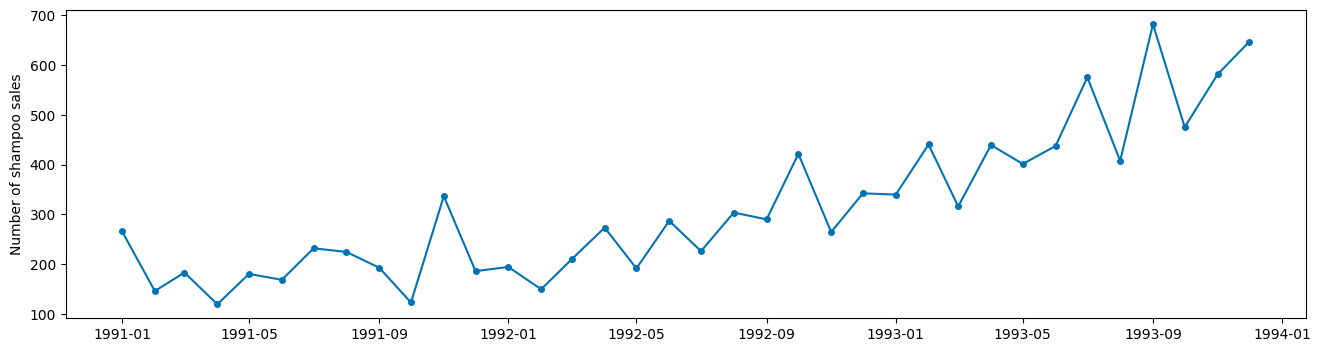

In [73]:
from sktime.utils.plotting import plot_series

plot_series(ts)

시계열 예측 예제(sktime)

데이터세트 불러오기

In [74]:
import numpy as np
import pandas as pd
import sktime.datasets as skdata
from sktime.utils.plotting import plot_series

# airline 데이터세트 로드 -> Pandas Series 형태로 로드됨
ts = skdata.load_airline()

# 데이터세트 정보 출력
print(ts.info())

<class 'pandas.core.series.Series'>
PeriodIndex: 144 entries, 1949-01 to 1960-12
Freq: M
Series name: Number of airline passengers
Non-Null Count  Dtype  
--------------  -----  
144 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB
None


In [75]:
# 데이터 확인
print(ts.head())
print('-'*80)

# index 확인, PeriodIndex 형태로 되어 있음
print(ts.index)
print('-'*80)

# values 확인
print(ts.values)

Period
1949-01    112.0
1949-02    118.0
1949-03    132.0
1949-04    129.0
1949-05    121.0
Freq: M, Name: Number of airline passengers, dtype: float64
--------------------------------------------------------------------------------
PeriodIndex(['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06',
             '1949-07', '1949-08', '1949-09', '1949-10',
             ...
             '1960-03', '1960-04', '1960-05', '1960-06', '1960-07', '1960-08',
             '1960-09', '1960-10', '1960-11', '1960-12'],
            dtype='period[M]', name='Period', length=144)
--------------------------------------------------------------------------------
[112. 118. 132. 129. 121. 135. 148. 148. 136. 119. 104. 118. 115. 126.
 141. 135. 125. 149. 170. 170. 158. 133. 114. 140. 145. 150. 178. 163.
 172. 178. 199. 199. 184. 162. 146. 166. 171. 180. 193. 181. 183. 218.
 230. 242. 209. 191. 172. 194. 196. 196. 236. 235. 229. 243. 264. 272.
 237. 211. 180. 201. 204. 188. 235. 227. 234. 264. 302

- 시계열 데이터 시각화

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

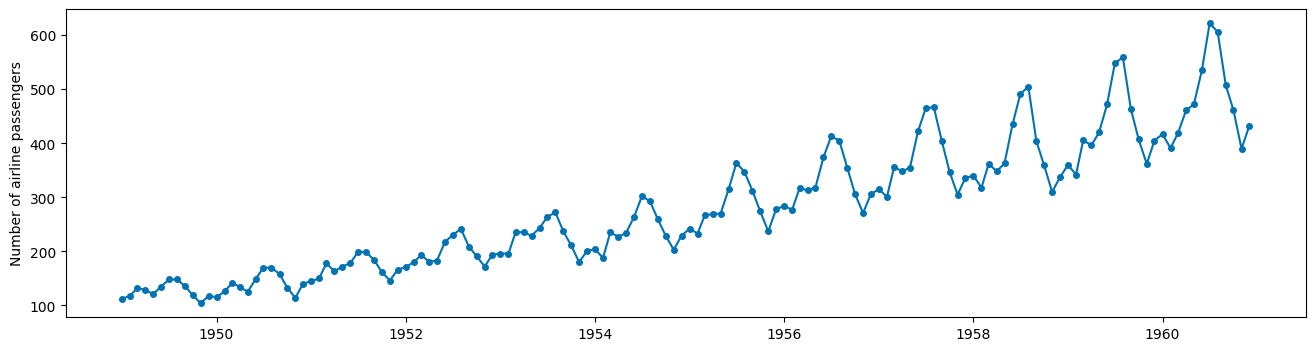

In [76]:
plot_series(ts)

학습데이터와 평가데이터 분리
- sklearn과 동일하게 학습데이터와 평가데이터를 분리
    - temporal_train_test_split()을 사용 <- sklearn은 train_test_split()

#Train Data: 108 , # Test Data: 36
--------------------------------------------------------------------------------


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

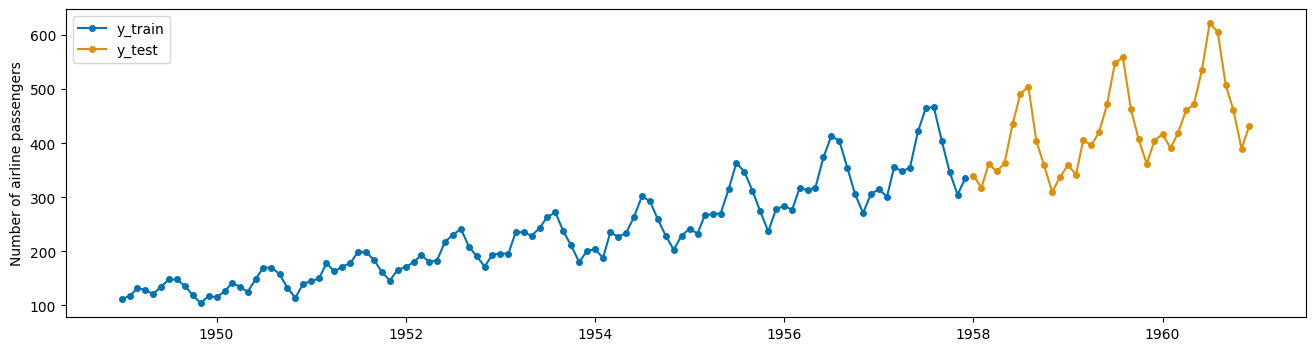

In [77]:
# 시계열 데이터세트를 train, test로 나누는 함수
from sktime.forecasting.model_selection import temporal_train_test_split

# 36개월을 test 데이터세트로 사용하고 나머지를 train 데이터세트로 사용
y_train, y_test = temporal_train_test_split(ts, test_size=36)

# 데이터세트 개수 확인
print('#Train Data:', y_train.shape[0], ', # Test Data:', y_test.shape[0])
print('-'*80)

# 시각화
plot_series(y_train, y_test, labels=["y_train", "y_test"])

예측시평(forecasting horizon) 설정
- 시평(forecasting horizon)은 예측할 시점의 길이를 의미
- forecasting horizon을 설정하는 방법은 forecasting 모듈의 ForecastingHorizon 클래스를 사용
    - is_relative는 시평을 어떻게 적용할 것인지 여부
        - True: train data 이후에 상대적인 시평을 적용
        - False: 지정한 절대적인 시평을 사용

In [78]:
from sktime.forecasting.base import ForecastingHorizon #시평을 설정하는 함수

# 절대적 시평 설정 -> 시평을 평가데이터세트인 y_test와 동일 기간으로 설정한 경우
fh_absolute = ForecastingHorizon(y_test.index, is_relative=False)
fh_absolute

ForecastingHorizon(['1958-01', '1958-02', '1958-03', '1958-04', '1958-05', '1958-06',
             '1958-07', '1958-08', '1958-09', '1958-10', '1958-11', '1958-12',
             '1959-01', '1959-02', '1959-03', '1959-04', '1959-05', '1959-06',
             '1959-07', '1959-08', '1959-09', '1959-10', '1959-11', '1959-12',
             '1960-01', '1960-02', '1960-03', '1960-04', '1960-05', '1960-06',
             '1960-07', '1960-08', '1960-09', '1960-10', '1960-11', '1960-12'],
            dtype='period[M]', is_relative=False)

In [79]:
# 상대적 시평 설정 -> 시평을 마지막 train data 이후 10개로 설정한 경우
fh_relative = ForecastingHorizon(range(1,11), is_relative=True)
fh_relative

ForecastingHorizon(start=1, stop=11, step=1, is_relative=True)

예측모형 설정

- 모든 예측모형은 클래스이므로 이를 사용하기 위해서는 객체(object, instance)를 생성하여 사용
    - 객체 생성시 모형의 파라미터를 설정하여 다양한 모형을 구성할 수 있음

In [80]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing # 지수평활법 예측 알고리즘
from sktime.forecasting.naive import NaiveForecaster # 단순 예측 알고리즘

# 예측 알고리즘 객체 생성

# 마지막 데이터를 예측값으로 사용하는 단순 예측 알고리즘
naive_forecaster = NaiveForecaster(strategy='last')

# 지수평활법 예측 알고리즘
exp_smoothing_forecaster = ExponentialSmoothing(trend="add", seasonal="additive", sp=12)

훈련과 예측
- 훈련은 훈련 데이터세트로 fit()을 사용하여 모형의 계수를 추정
- 예측은 fit()이 완료된 학습된 모형(추정한 계수)을 사용하여 평가 데이터세트에 대하여 predict()로 추정하여 계산

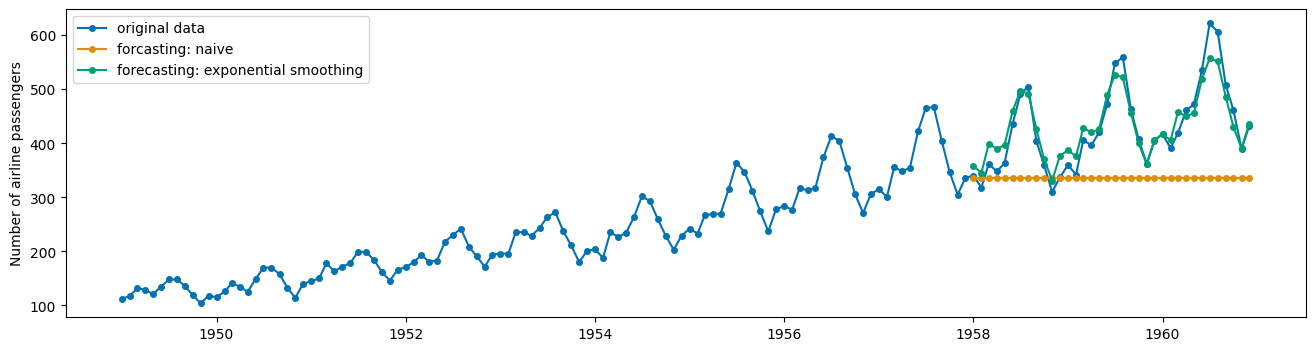

In [81]:
# 훈련
# 단순 예측 알고리즘 학습(모형의 계수 추정)
naive_forecaster.fit(y_train)
# 지수평활법 예측 알고리즘 학습(모형의 계수 추정)
exp_smoothing_forecaster.fit(y_train)

# 예측
# 단순 예측 알고리즘을 사용하여 예측
y_pred_naive = naive_forecaster.predict(fh_absolute)
# 지수평활법 예측 알고리즘을 사용하여 예측
y_pred_exp_smoothing = exp_smoothing_forecaster.predict(fh_absolute)

# 시각화
plot_series(
    ts, y_pred_naive, y_pred_exp_smoothing,
    labels=["original data", "forcasting: naive", "forecasting: exponential smoothing"]
);

- 학습된 예측 모형에 상대적 시평을 적용한 경우

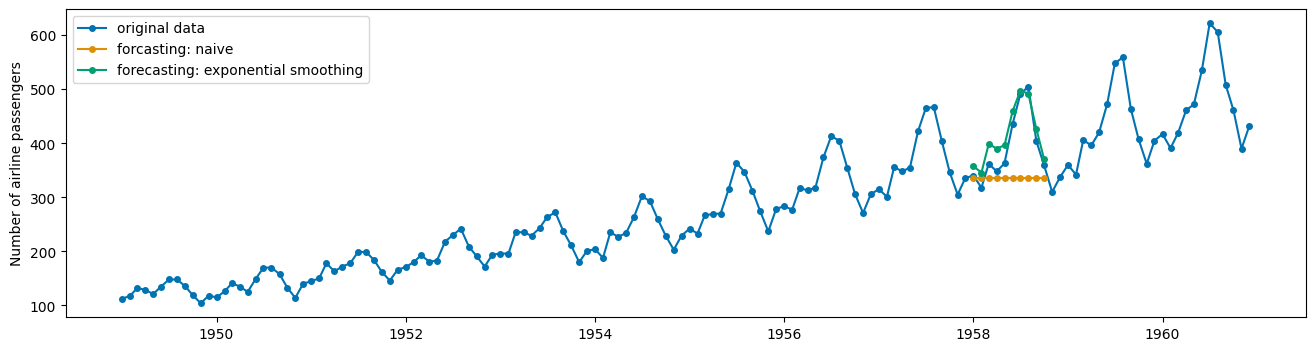

In [82]:
# 단순 예측 알고리즘을 사용하여 예측
y_pred_naive_relative = naive_forecaster.predict(fh_relative)
# 지수평활법 예측을 사용하여 예측
y_pred_exp_smoothing_relative = exp_smoothing_forecaster.predict(fh_relative)

# 시각화
plot_series(
    ts, y_pred_naive_relative, y_pred_exp_smoothing_relative,
    labels=["original data", "forcasting: naive", "forecasting: exponential smoothing"]
);

예측모형 성능 평가
- sktime.performance_metrics.forecasting에 다양한 평가지표를 제공

In [83]:
# MSE, MAPE 임포트
from sktime.performance_metrics.forecasting import mean_squared_error as mse
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error as mape

# MSE, MAPE 계산
print("Naive MSE:", mse(y_test, y_pred_naive))
print("ExpSmoothing MSE:", mse(y_test, y_pred_exp_smoothing))
print("Naive MAPE:", mape(y_test, y_pred_naive))
print("ExpSmoothing MAPE:", mape(y_test, y_pred_exp_smoothing))

Naive MSE: 14674.555555555555
ExpSmoothing MSE: 695.6818349188462
Naive MAPE: 0.19886711926999853
ExpSmoothing MAPE: 0.051141584511003875


# 시계열 데이터 전처리

시계열 데이터 전처리
- 시계열 데이터의 전처리는 다음과 같은 단계로 진행
1. 결측치 처리
2. 이상치 처리
3. 디노이징

결측치와 이상치가 있는 시계열 데이터 생성
- 데이터세트 로드

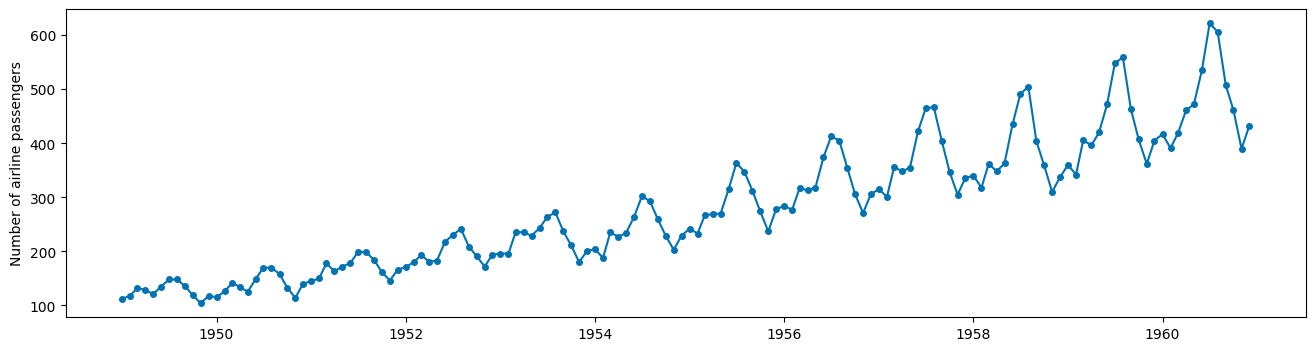

In [84]:
import numpy as np
import pandas as pd
import sktime.datasets as skdata
from sktime.utils.plotting import plot_series
from sktime.forecasting.model_selection import temporal_train_test_split

# airline 데이터세트 로드
y = skdata.load_airline()
plot_series(y);

- 원 데이터를 학습데이터와 평가데이터로 분리

In [85]:
# 학습데이터와 평가데이터(36개) 분리
y_train, y_test = temporal_train_test_split(y, test_size=36)

# 학습데이터 크기
size_ts = len(y_train)

- 학습 데이터에 노이즈 추가

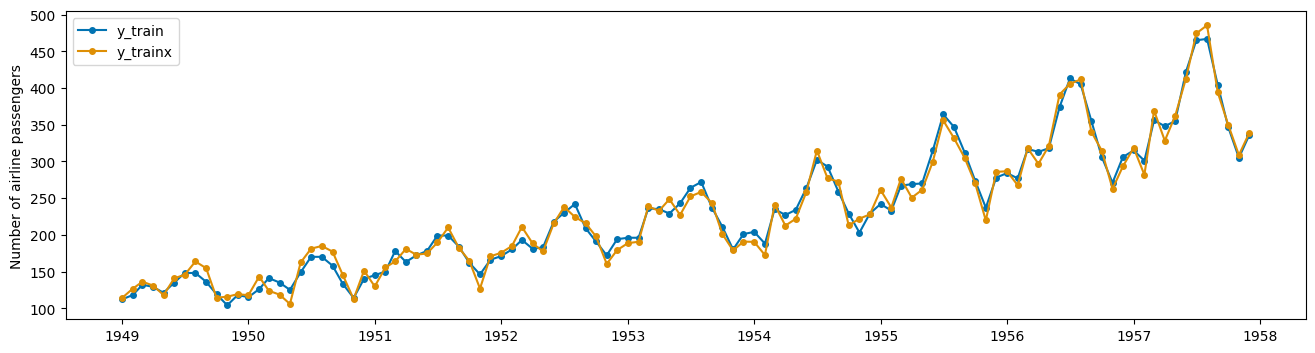

In [86]:
# 학습데이터 복사
y_trainx = y_train.copy()

# 랜덤 넘버 생성을 위한 seed 설정
np.random.seed(0)

# 학습데이터 크기만큼의 노이즈 생성
noise = np.random.uniform(low=-20, high=20, size=size_ts)

# 학습데이터에 노이즈 추가
y_trainx.values[:] += noise

# 학습데이터와 노이즈가 추가된 학습데이터 시각화
plot_series(y_train, y_trainx, labels=["y_train", "y_trainx"]);

- 이상치 추가

outliers_indices = array([52, 67, 61, 14, 96], dtype=int32)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

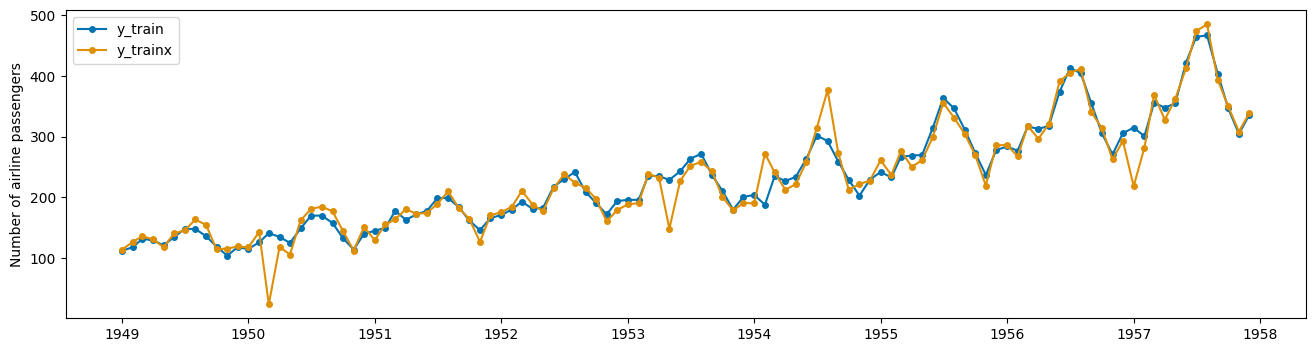

In [87]:
# 이상치를 넣을 인덱스(정수)를 랜덤하게 5개 생성
outliers_indices = np.random.randint(low=0, high=size_ts, size=5)
print(f'{outliers_indices = }')

# 홀수인덱스에는 +100, 짝수인덱스에는 -100을 더함
y_trainx.values[outliers_indices] += 200*(outliers_indices%2)-100

# 시계열 데이터 시각화
plot_series(y_train, y_trainx, labels=["y_train", "y_trainx"])

- 결측치 생성

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

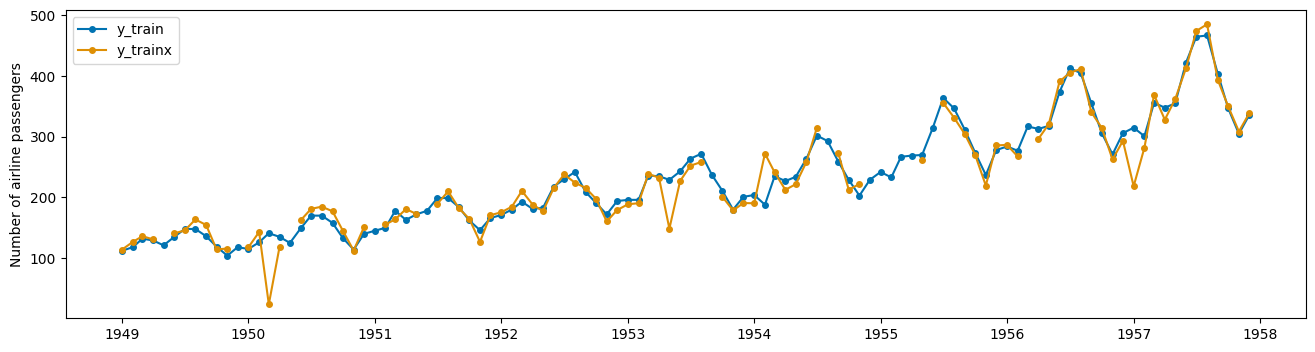

In [88]:
# 결측치를 위한 인덱스 생성
missing_indices = np.random.randint(0, size_ts, 10)

# 결측치 추가
y_trainx.values[missing_indices] = np.nan

# 연속된 결측치 추가 
y_trainx.values[71:76] = np.nan

# 시계열 데이터 시각화
plot_series(y_train, y_trainx, labels=["y_train", "y_trainx"])

시계열 데이터 결측치의 특징
- 시계열은 시간에 대해 연속 데이터이므로 결측치는 대체로 처리하지만, 이때 주의가 필요
    - 시계열은 비정상 특징을 가지기 때문에 시간에 따라 평균과 분산이 변함
    - 정형데이터와 같이 단순하게 평균/중앙값/최빈값으로 결측치를 대체하면, 그 시점의 평균과 분산의 왜곡을 야기
    - 따라서, 결측치 주변의 데이터를 이용하여 대체하는 것이 바람직

시계열 데이터의 결측치 대체방법
1. Last observation carried Forward(LOCF): 직전에 관측된 값으로 결측치를 대체
2. Next observation carried Backward(NOCB): 직후에 관측된 값으로 결측치를 대체
3. Moving Average(Median): 직전 m개의 데이터의 평균(중앙값)으로 결측치를 대체
4. 보간(interpolation): 선형 보간법, 비선형 보간법, 스플라인 보간법 등 다양한 보간법을 적용
5. 인공지능(AI): 결측치가 많은 경우 GAN(Genervative Adversarial Networks)에 기반한 시계열 생성 알고리즘을 적용하기도 함

결측치 처리 예제
----
pandas 라이브러리를 이용한 결측치 처리

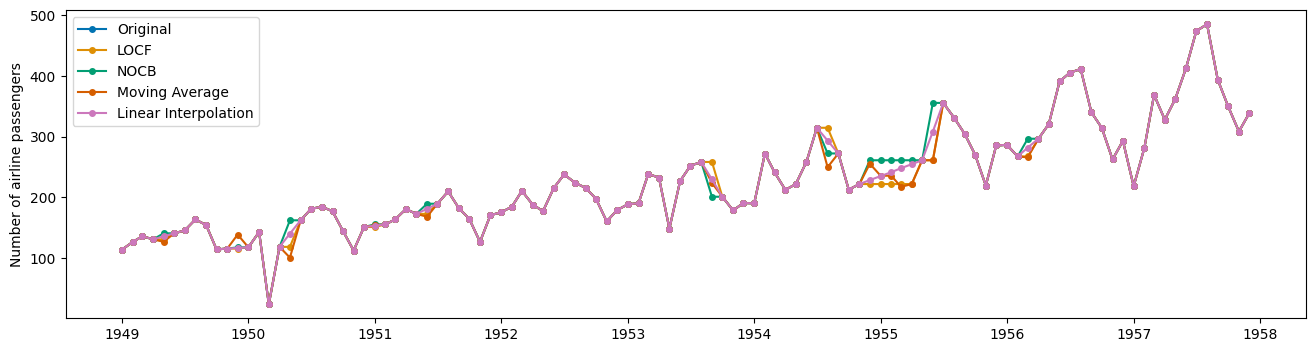

In [89]:
import pandas as pd

# 1. LOCF, pandas.ffill() 함수 사용
y_trainx_locf = y_trainx.ffill()

# 2. NOCB, pandas.bfill() 함수를 사용
y_trainx_nocb = y_trainx.bfill()

# 3. Moving Average, pandas.rolling() 함수 사용. 
# min_periods=1은 최소 1개의 값이 있으면 계산
y_trainx_ma = y_trainx.fillna(y_trainx.rolling(6, min_periods=1).mean())

# 4. Linear Interpolation, pandas.interpolate() 함수 사용
y_trainx_linear = y_trainx.interpolate(metheod='linear')

# 시계열 데이터 시각화
plot_series(
    y_trainx, y_trainx_locf, y_trainx_nocb, y_trainx_ma, y_trainx_linear,
    labels=['Original', 'LOCF', 'NOCB', 'Moving Average', 'Linear Interpolation']
);

sktime Imputer를 이용한 결측치 처리

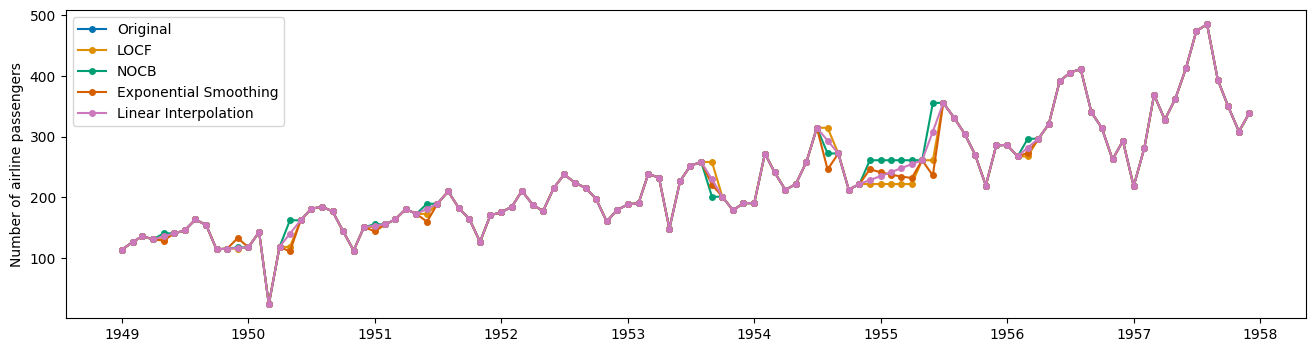

In [90]:
from sktime.transformations.series.impute import Imputer
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

# 1. LOCF
y_trainx_lodf = Imputer(method="ffill").fit_transform(y_trainx)

# 2. NOCB
y_trainx_nocb = Imputer(method="bfill").fit_transform(y_trainx)

# 3. Exponential Smoothing
y_trainx_es = Imputer(method="forecaster",
                      forecaster=ExponentialSmoothing(smoothing_level=0.2)
                      ).fit_transform(y_trainx)

# 4. Linear Interpolation
y_trainx_linear = Imputer(method="linear").fit_transform(y_trainx)

# 시계열 데이터 시각화
plot_series(
    y_trainx, y_trainx_locf, y_trainx_nocb, y_trainx_es, y_trainx_linear,
    labels=['Original', 'LOCF', 'NOCB', 'Exponential Smoothing', 'Linear Interpolation']
);

이상치 처리

시계열 데이터의 이상치 특성
----
- 시계열 데이터의 이상치는 극단치와 특이치로 구분할 수 있음
    - 극단치: 정상적인 시계열 데이터에 비해 매우 크거나 작은 값으로 나타나는 데이터로서 결과를 왜곡시키므로 적절한 범위의 값으로 대체해야 함
    - 특이치: 정상적인 시계열 데이터에 새로운 패턴으로 나타나는 데이터로서 주요 분석의 대상이므로 유지해야 함
- 시계열 데이터는 연속성이 보장되어야 하므로 이상치 또한 제거는 하지 않고 대체하는 방식으로 처리해야 함

시계열 데이터 이상치 처리 방법
----
- 계절과 추세를 제거한 잔차에 대하여 이상치 탐색 및 보정방법 적용
    - 이상치 보정 후에는 다시 계절과 추세를 더해주어 원래 시계열로 복원
- Hampel filter를 이용하여 이상치를 탐색하고 대체
    - Hampel filter는 현재 시점 주변 데이터들의 중앙값 대비 얼마나 이상한가를 판단하는 함수로서 일정한 크기의 sliding window를 이용하여 이상치를 탐색
    - 정해진 window구간 내 Median absolute deviation(MdAD)을 구하여 이상치를 판단하고 이상치는 중앙값으로 대체

계절주기 추출
- 차분데이터와 상관분석을 이용한 계절주기 검출방법

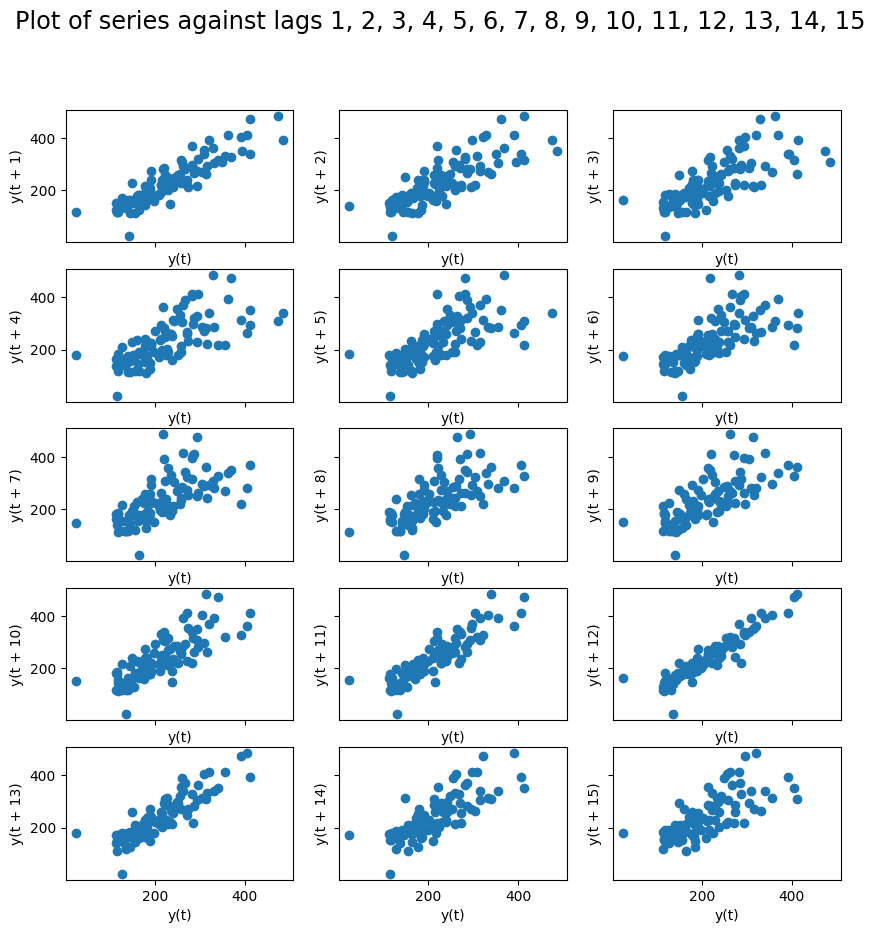

In [91]:
# 시계열 데이터의 시간 지연을 시각화하는 함수
from sktime.utils.plotting import plot_lags

# 1부터 15까지의 시간 지연을 시각화
fig, ax = plot_lags(y_trainx_linear, lags=list(range(1,16)))

# 그래프 크기 조정
fig.set_size_inches(10, 10)

차분데이터와 상관분석을 통해 주기서분 확인 결과 12개월의 상관관계가 매우 커서 12개월(1년)의 주기성분이 존재함을 확인할 수 있음

- 자기상관함수(Auto-Correlation Function, ACF)를 이용한 계절주기 검출방법

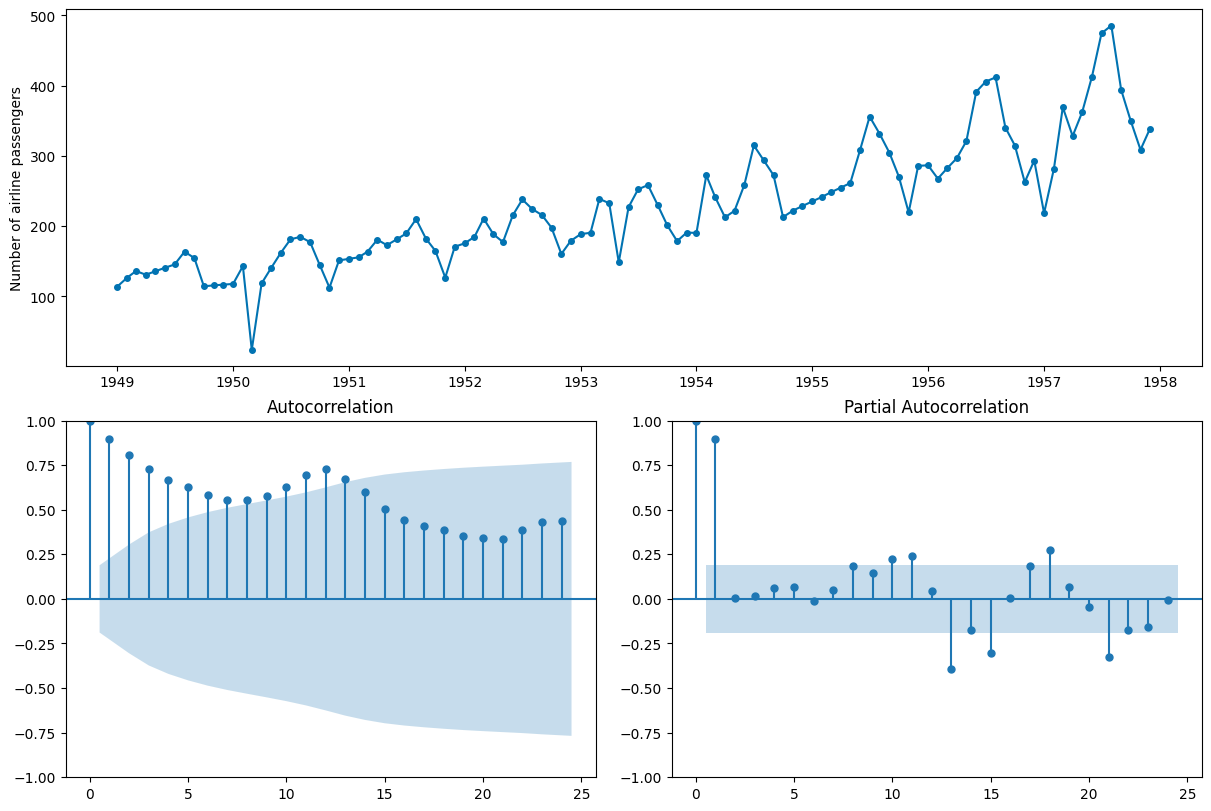

In [92]:
# 자기상관함수를 시각화하는 함수
from sktime.utils.plotting import plot_correlations

# 자기상관함수 시각화
fig, ax = plot_correlations(y_trainx_linear)

결과해석  
ACF(아래 왼쪽 그래프)를 통해 주기성분 확인 결과 12~13개월 주기성분이 존재
    - 14개월 이후로는 백색잡음 신뢰구간으로 들어감

시계열 분해를 통한 잔차 추출
1. STL 분해를 이용한 잔차 추출
- STL(Seasonal and Trend decompositon using Loess)은 다양한 상황에서 사용할 수 있는 강력한 시계열 기법
    - Loess는 비선형 관계를 추정하기 위한 회귀 기법 중 하나
    - additive 모형(가법 모형)만 지원
- 12개월 주기로 계절, 추세 분해

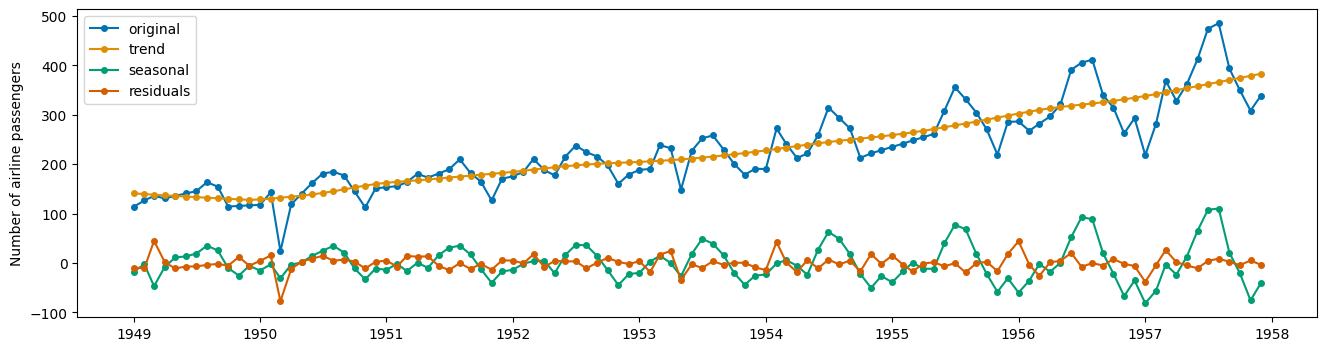

In [93]:
# STLForecaster 클래스 임포트
from sktime.forecasting.trend import STLForecaster

# 12개월 주기의 STLForecaster 객체 생성
forecaster = STLForecaster(sp=12)

# 선형보간으로 결측치를 대체한 데이터로 모델 훈련
forecaster.fit(y_trainx_linear)

# 시계열 데이터의 추세, 계절성, 잔차를 시각화
plot_series(
    y_trainx_linear, forecaster.trend_, forecaster.seasonal_, forecaster.resid_,
    labels=['original', 'trend', 'seasonal', 'residuals']
)

resid_stl = forecaster.resid_ # STL 분해의 잔차

2. Deseasonalizer와 Detrender를 이용한 잔차 추출
- 계절 성분 제거

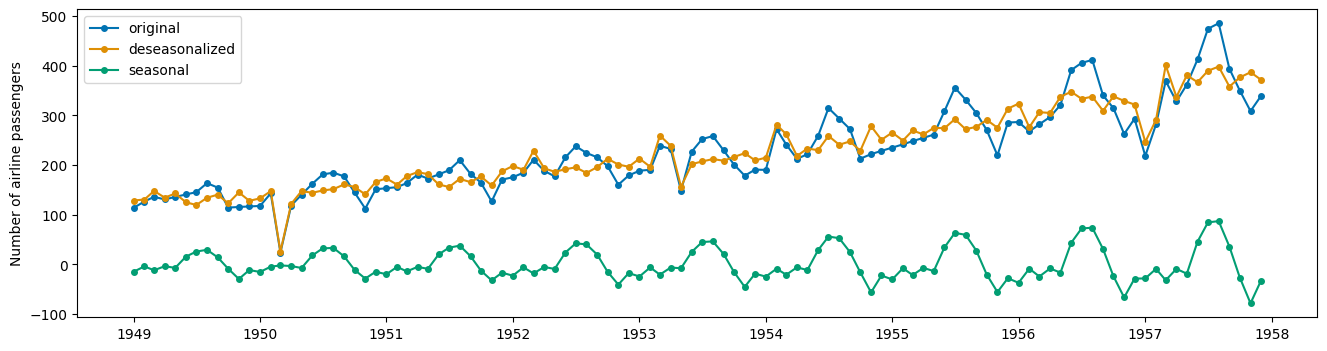

In [94]:
# Deseasonalizer 클래스 임포트
from sktime.transformations.series.detrend import Deseasonalizer

# 12개월 주기의 계절성을 제거하는 Deseasonalizer 객체 생성
transformer = Deseasonalizer(sp=12, model="multiplicative")

# 데이터에 대해 계절성 제거
y_deseasonalized = transformer.fit_transform(y_trainx_linear)
y_seasonal = y_trainx_linear - y_deseasonalized

# 시계열 데이터 시각화
plot_series(
    y_trainx_linear, y_deseasonalized, y_seasonal,
    labels=["original", "deseasonalized", "seasonal"]
);

- 추세성분 제거

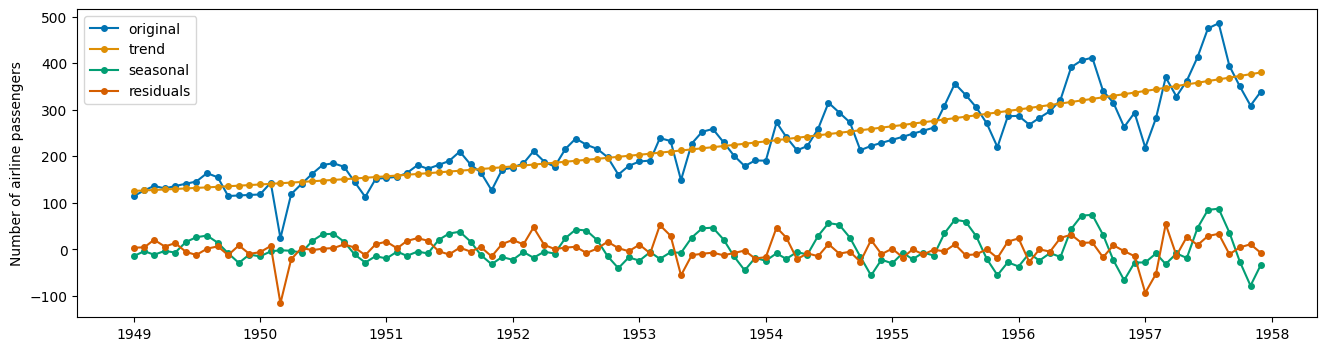

In [95]:
# Detrender 클래스 임포트
from sktime.transformations.series.detrend import Detrender
# PolynomialTrendForecaster 클래스 임포트
from sktime.forecasting.trend import PolynomialTrendForecaster

# 2차 다항식 추세를 제거하는 Detrender 객체 생성
transformer = Detrender(forecaster=PolynomialTrendForecaster(degree=2))

# 계절성이 제거된 데이터에 대해 추세 제거
y_detrended = transformer.fit_transform(y_deseasonalized)

# Deseasonalizer와 Detrender를 거친 잔차
resid_de = y_detrended

# 추세 시계열
y_trend = y_deseasonalized - y_detrended

# 시계열 데이터 시각화
plot_series(
    y_trainx_linear, y_trend, y_seasonal, resid_de,
    labels=["original", "trend", "seasonal", "residuals"]
);

이상치 탐색
1. 잔차에 G-ESD를 적용하여 이상치 탐색

- G-ESD(Generalized Extreme Studentized Deviate)는 이상치 탐색을 위한 통계적 방법
    - 정규분포를 따르는 단변량의 이상치를 검정하는 Grubb's test를 확장한 방법
    - 여러 개의 이상치를 동시에 탐색할 수 있음
- G-ESD는 scikit_posthocs 패키지를 이용하므로 scikit_posthocs를 설치해야함

In [96]:
# scikit-posthocs 패키지 임포트
import scikit_posthocs as sp

# STL 분해의 잔차를 이용하여 이상치 탐지
x = resid_stl

# G-ESD 실행. outliers_gesd는 test summary를 제공. inliers를 반환
inliers = sp.outliers_gesd(x, outliers=10, report=True)

H0: no outliers in the data
Ha: up to 10 outliers in the data
Significance level:  α = 0.05
Reject H0 if Ri > Critical Value (λi)

Summary Table for Two-Tailed Test
---------------------------------------
      Exact           Test     Critical
  Number of      Statistic    Value, λi
Outliers, i      Value, Ri          5 %
---------------------------------------
          1          5.076         3.41 *
          2          3.363        3.407
          3          3.524        3.404 *
          4          3.634        3.401 *
          5          3.342        3.397
          6          3.202        3.394
          7          2.642        3.391
          8          2.631        3.387
          9          2.603        3.384
         10          2.289        3.381


In [97]:
# inliers의 최소값보다 작거나, 최댓값보다 큰 값을 이상치로 판단
outliers = x[(x<inliers.min())|(x>inliers.max())]

print('G-ESD Outliers: ', outliers)

G-ESD Outliers:  1949-03    44.770328
1950-03   -77.322315
1954-02    42.460047
1956-01    44.103861
Freq: M, dtype: float64


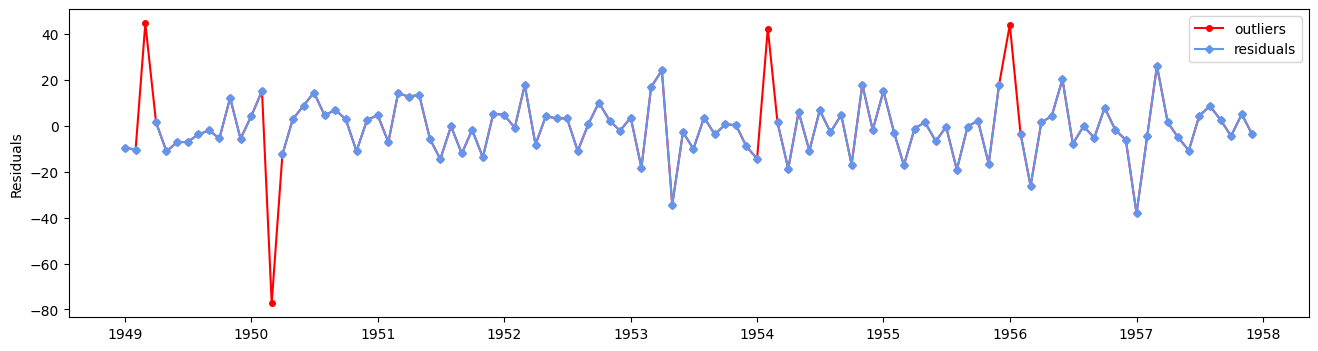

In [98]:
# 이상치 시각화
inliers = resid_stl.copy()
inliers.loc[outliers.index] = np.nan

plot_series(
    resid_stl, inliers,
    markers=["o", "D"],
    colors=["r", "cornflowerblue"],
    labels=["outliers", "residuals"],
    y_label="Residuals"
);

2. Hampel filter를 이용한 이상치 탐색

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

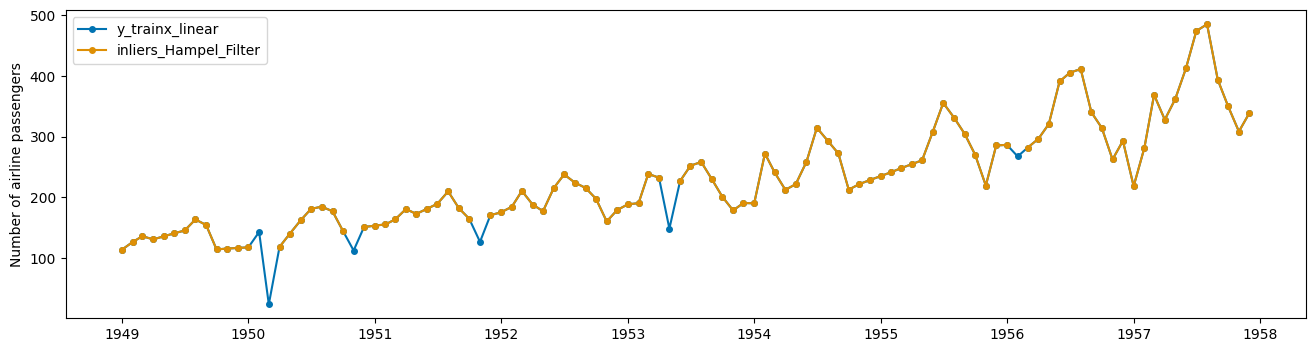

In [99]:
# HampelFilter 클래스 임포트
from sktime.transformations.series.outlier_detection import HampelFilter

# Hampel Filter 객체 생성, n_sigma는 outlier로 판단할 표준편차의 배수
transformer = HampelFilter(window_length=5, n_sigma=3)

# Hampel Filter를 이용하여 이상치 탐지 및 결측치로 대체
inliers_hampel = transformer.fit_transform(y_trainx_linear)

# 시계열 데이터 시각화
plot_series(
    y_trainx_linear, inliers_hampel,
    labels=["y_trainx_linear", "inliers_Hampel_Filter"]
)

이상치 대체
---
선형보간법을 이용한 대체

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

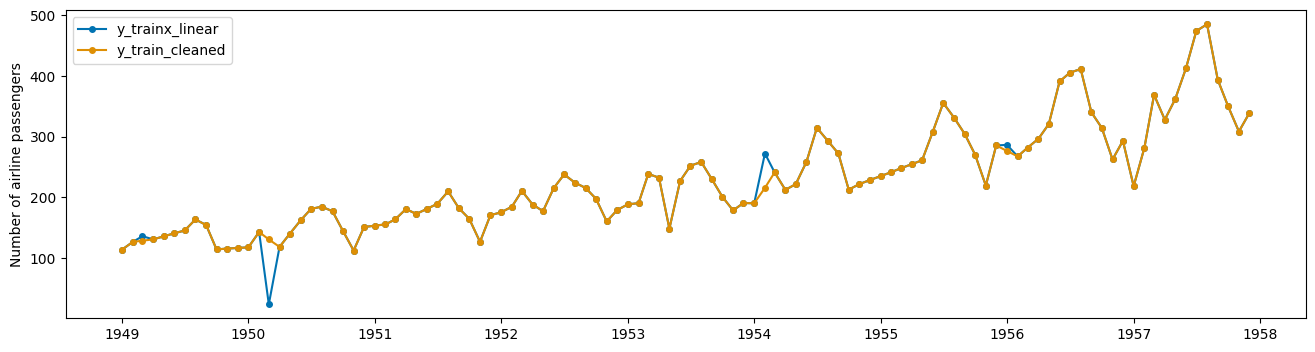

In [100]:
# 선형보간으로 결측치를 대체한 데이터 복사
y_train_cleaned = y_trainx_linear.copy()

# 이상치를 결측치로 대체
y_train_cleaned[outliers.index] = np.nan

# 결측치를 선형보간으로 대체
y_train_cleaned = y_train_cleaned.interpolate(method='linear', limit_direction='both')

# 시계열 데이터 시각화
plot_series(
    y_trainx_linear, y_train_cleaned,
    labels=['y_trainx_linear', 'y_train_cleaned']
)

디노이징

노이즈
---
- 노이즈는 잡음을 뜻하며 여러가지 의도하지 않은 데이터의 왜곡을 불러오는 모든 것을 의미
    - 센서 자체에서 발생하는 신호의 간섭
    - 매출 로그 데이터에 발생한 일시적 이상 기록과 같은 이상치들

- 노이즈는 특히 시계열 데이터 분석에 있어 치명적인 영향을 끼치는데 시계열 데이터의 경우 전체 데이터가 아닌 특정 구간의 데이터를 보기 때문에 시간의 흐름에 따라 변화하는 통계적 특성을 강하게 왜곡

디노이징(잡음 제거) 방법
---
- 평활화(smoothing)
    - 단순이동평균(sma, simple moving average)
    - 단순지수평활(ses, simple exponential smoothing)
- 필터링
    - 잡음은 일반적으로 고주파 성분으로 구성되어 있으므로 고주파 성분을 제거하는 필터를 사용하여 잡음을 제거하여 시계열을 부드럽게 만드는 방법

디노이징 예제
---
단순이동평균(simple moving average)을 이용한 디노이징
- 윈도우를 이동시키며, 최근 m개의 데이터를 평균하여 현재 시점의 데이터로 대체

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

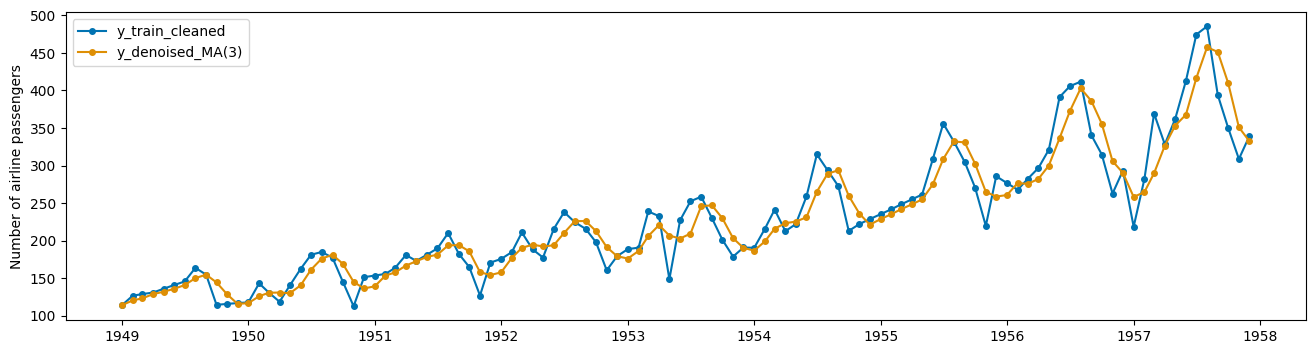

In [101]:
# 이상치가 제거된 데이터 복사
y_cleaned = y_train_cleaned.copy()

# pandas의 rolling 함수를 이용하여 이동평균 계산
y_denoised_ma3 = y_cleaned.rolling(window=3, min_periods=1).mean()

# 디노이징 시각화
plot_series(
    y_cleaned, y_denoised_ma3,
    labels=["y_train_cleaned", "y_denoised_MA(3)"]
)

지수이동평균(Exponential Moving Average)을 이용한 디노이징
- 평활계수 a가 최근 데이터로부터 적용
- time lag가 발생함

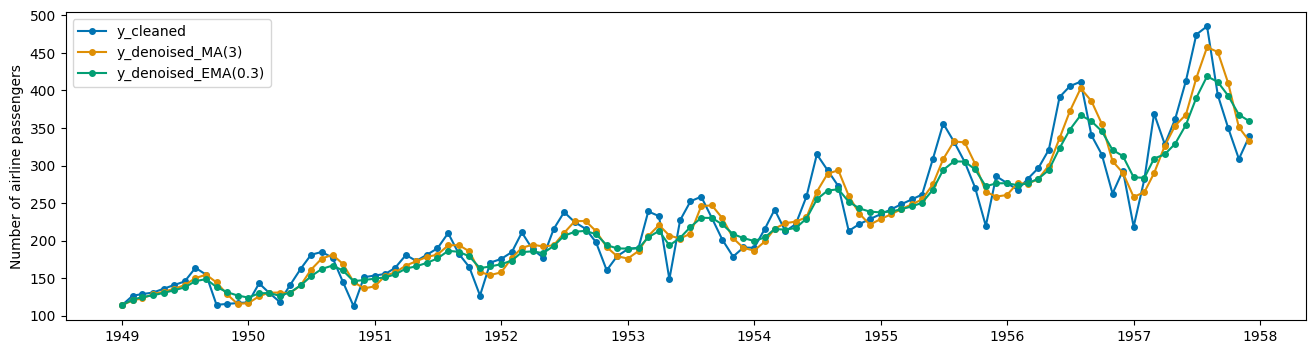

In [102]:
# pandas의 ewm 함수를 이용하여 지수이동평균 계산
y_denoised_ema03 = y_cleaned.ewm(alpha=0.3).mean()

# 디노이징 시각화
plot_series(
    y_cleaned, y_denoised_ma3, y_denoised_ema03,
    labels=["y_cleaned", "y_denoised_MA(3)", "y_denoised_EMA(0.3)"]
);

주파수 Filter를 이용한 디노이징
- 시계열 데이터를 FFT를 이용하여 주파수 영역으로 변환하고 주파수 영역에서 노이즈 성분을 제거한 후 다시 시계열 영역으로 변환

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Frequency Domain Plot'}, xlabel='Frequency[Hz]', ylabel='Amplitude'>)

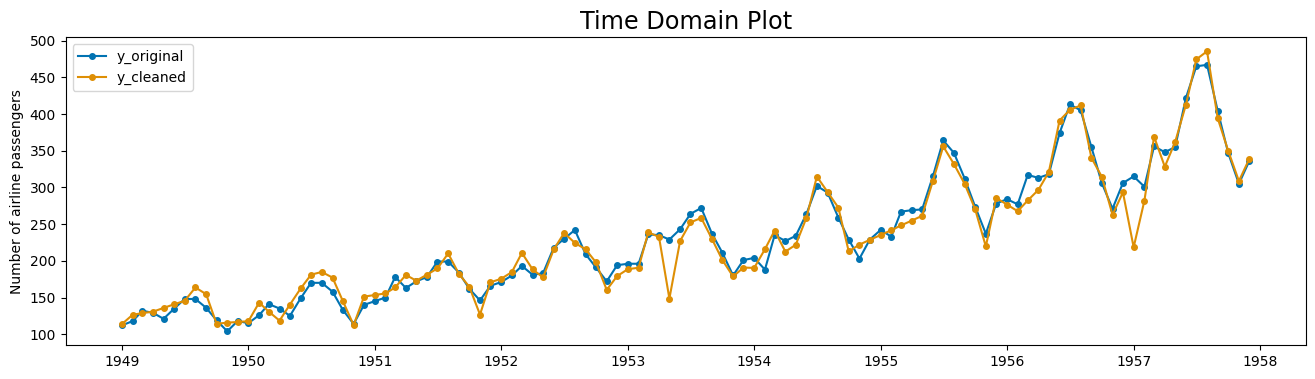

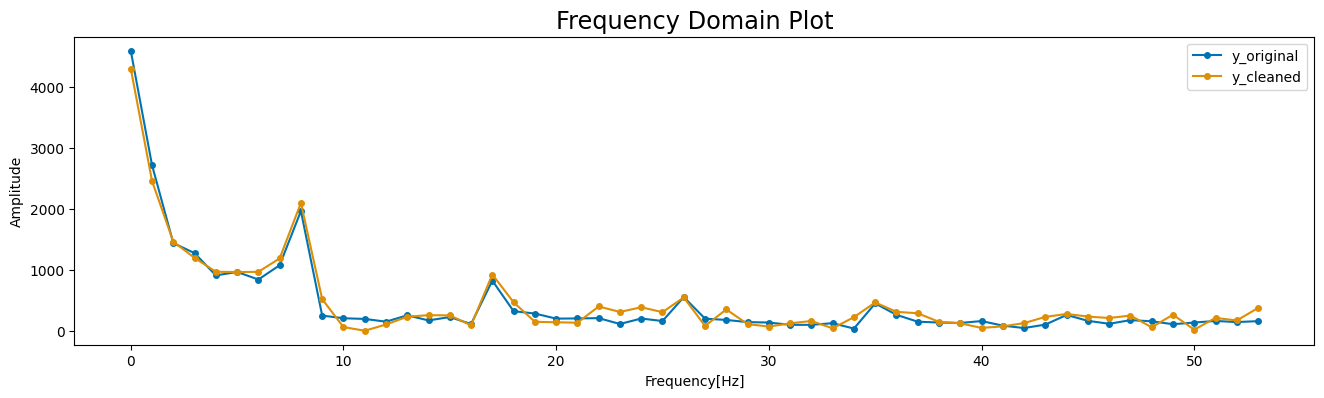

In [103]:
# FourierTransform 클래스 임포트
from sktime.transformations.series.fourier import FourierTransform

# FourierTransform 객체 생성
fft = FourierTransform()

# 원데이터에 대해 퓨리에 변환
y_original_fft = fft.fit_transform(y_train)

# 노이즈 데이터에 대해 퓨리에 변환
y_cleaned_fft = fft.fit_transform(y_cleaned)

# 시간 영역과 주파수 영역 데이터 시각화
plot_series(
    y_train, y_cleaned, labels=["y_original", "y_cleaned"],
    title="Time Domain Plot"
)
plot_series(
    y_original_fft, y_cleaned_fft, labels=["y_original", "y_cleaned"],
    title="Frequency Domain Plot",
    y_label = "Amplitude",
    x_label="Frequency[Hz]"
)

노이즈가 포함된 y_cleaned가 원데이터보다 저주파 성분은 유사하나 고주파 성분들이 많음

sktime의 Filter()는 sfreq(샘플링 주파수), l_freq(저wnvktn), h_freq(고주파수)를 인자로 받음
- sfreq: 시간당 샘플링 횟수
- l_freq: 저주파수 컷오프 주파수. 지정하지 않으면, LPF
- h_freq: 고주파수 컷오프 주파수. 지정하지 않으면, HPF

Setting up low-pass filter at 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 73 samples (0.676 s)



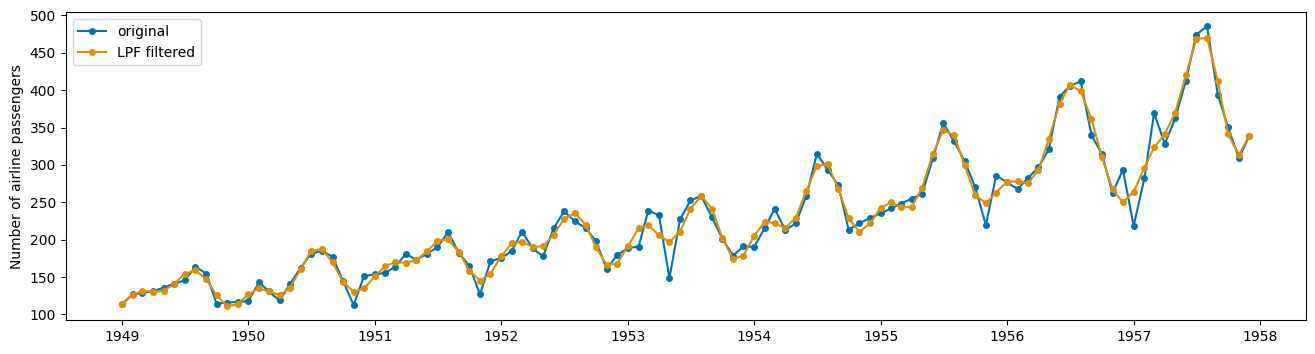

In [104]:
# 필터링을 위한 Filter 클래스 임포트
from sktime.transformations.series.filter import Filter

# 20Hz 이상의 주파수를 제거하기 위한 필터 객체 생성
filter_lpf = Filter(sfreq=len(y_cleaned), h_freq=20)

# 노이즈 데이터에 대한 필터링 실행
y_denoised_lpf = filter_lpf.fit_transform(y_cleaned)

# 시계열 데이터 시각화
plot_series(
    y_cleaned, y_denoised_lpf,
    labels=["original", "LPF filtered"],
);

시계열 전처리 방법 요약
- 결측치-> 시계열 데이터는 시간에 대해 연속적이므로 결측치는 대체
- 이상치-> 이상치는 모형에 따른 잔차(residuals, 관측치-예측치)를 도출한 후, 목적에 따라 잔차에 대한 다양한 기법을 적용
    - 예측: 이상치를 변환이나 대체
    - 이상치 탐색: 유지
- 노이즈 -> 디노이징을 통해 완화

# 평활법과 분해법